In [31]:
!pip install transformers datasets torch torchvision pillow matplotlib

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com

[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python -m pip install --upgrade pip


In [32]:
from torchvision import datasets

In [33]:
train_dir = "intel_dataset/seg_train"

dataset = datasets.ImageFolder(train_dir)

print("Classes:", dataset.classes)
print("Total Images:", len(dataset))

Classes: ['seg_train']
Total Images: 14034


In [34]:
!pip uninstall -y transformers torch torchvision

!pip install torch==2.4.1 torchvision==0.19.1
!pip install transformers==4.48.3

Found existing installation: transformers 4.48.3
Uninstalling transformers-4.48.3:
  Successfully uninstalled transformers-4.48.3
Found existing installation: torch 2.4.1
Uninstalling torch-2.4.1:
  Successfully uninstalled torch-2.4.1
Found existing installation: torchvision 0.19.1
Uninstalling torchvision-0.19.1:
  Successfully uninstalled torchvision-0.19.1
Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 797.1/797.1 MB 182.2 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 216.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
transformer-engine 1.11.0+4df8488 requires flash-attn!=2.0.9,!=2.1.0,<=2.6.3,>=2.0.6, which is not installed.
torch-tensorrt 2.5.0a0 requires torch<2.6.0,>=2.5.0.dev, but you have torch 2.4.1 which is incompatible.

[noti

In [35]:
import torch
import transformers

print("Torch Version:", torch.__version__)
print("Transformers Version:", transformers.__version__)

Torch Version: 2.5.1+cu124
Transformers Version: 4.48.3


In [36]:
!pip list | grep torch
!pip list | grep transformers

pytorch-triton             3.0.0+dedb7bdf3
torch                      2.4.1
torch_tensorrt             2.5.0a0
torchprofile               0.0.4
torchvision                0.19.1
transformers               4.48.3


In [45]:
from transformers import AutoImageProcessor
from transformers import AutoModelForImageClassification

model_name = "google/mobilenet_v2_1.0_224"

processor = AutoImageProcessor.from_pretrained(model_name)
model = AutoModelForImageClassification.from_pretrained(model_name)
print("Model trained successfully!!!")

Model trained successfully!!!


In [46]:
from PIL import Image
import torch

image_path = "intel_dataset/seg_test/seg_test/buildings/20057.jpg"

image = Image.open(image_path)

inputs = processor(images=image,
                   return_tensors="pt")

with torch.no_grad():
    outputs = model(**inputs)

predicted_class = outputs.logits.argmax(-1).item()

print("Predicted Class:",
      model.config.id2label[predicted_class])

Predicted Class: solar dish, solar collector, solar furnace


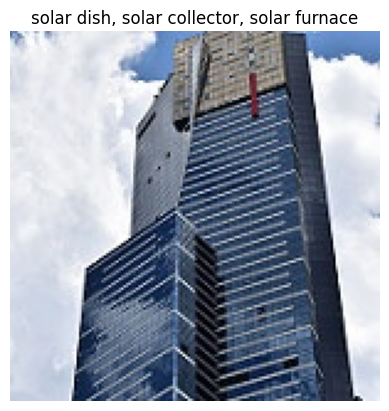

In [47]:
import matplotlib.pyplot as plt

plt.imshow(image)
plt.axis("off")
plt.title(model.config.id2label[predicted_class])
plt.show()

In [55]:
import torch
import torchvision.models as models
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import os

# Load pretrained VGG16
model = models.vgg16(pretrained=True)
model.eval()

# Define preprocessing (ImageNet normalization)
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406], 
        std=[0.229, 0.224, 0.225]
    )
])

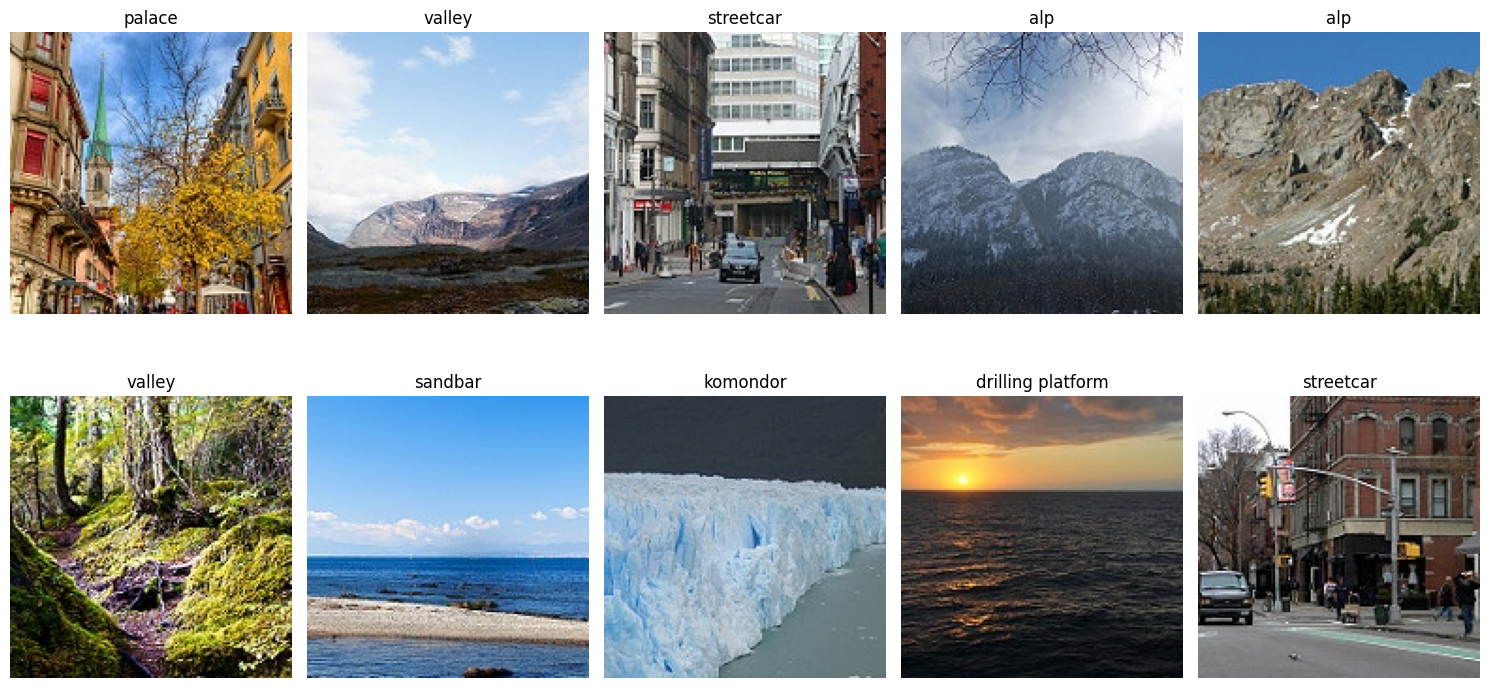

In [56]:
# Load ImageNet class labels
import requests

LABELS_URL = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"
imagenet_classes = requests.get(LABELS_URL).text.splitlines()

test_folder = "intel_dataset/seg_pred/seg_pred"
files = os.listdir(test_folder)[:10]

plt.figure(figsize=(15, 8))

for idx, file in enumerate(files):
    img_path = os.path.join(test_folder, file)
    img = Image.open(img_path)

    # Preprocess
    input_tensor = preprocess(img).unsqueeze(0)

    with torch.no_grad():
        outputs = model(input_tensor)
    pred = outputs.argmax(-1).item()
    label = imagenet_classes[pred]

    # Show image with prediction
    plt.subplot(2, 5, idx + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(label)

plt.tight_layout()
plt.show()

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|███████████████████████████████████████████████████████████████████████████████| 97.8M/97.8M [00:00<00:00, 314MB/s]


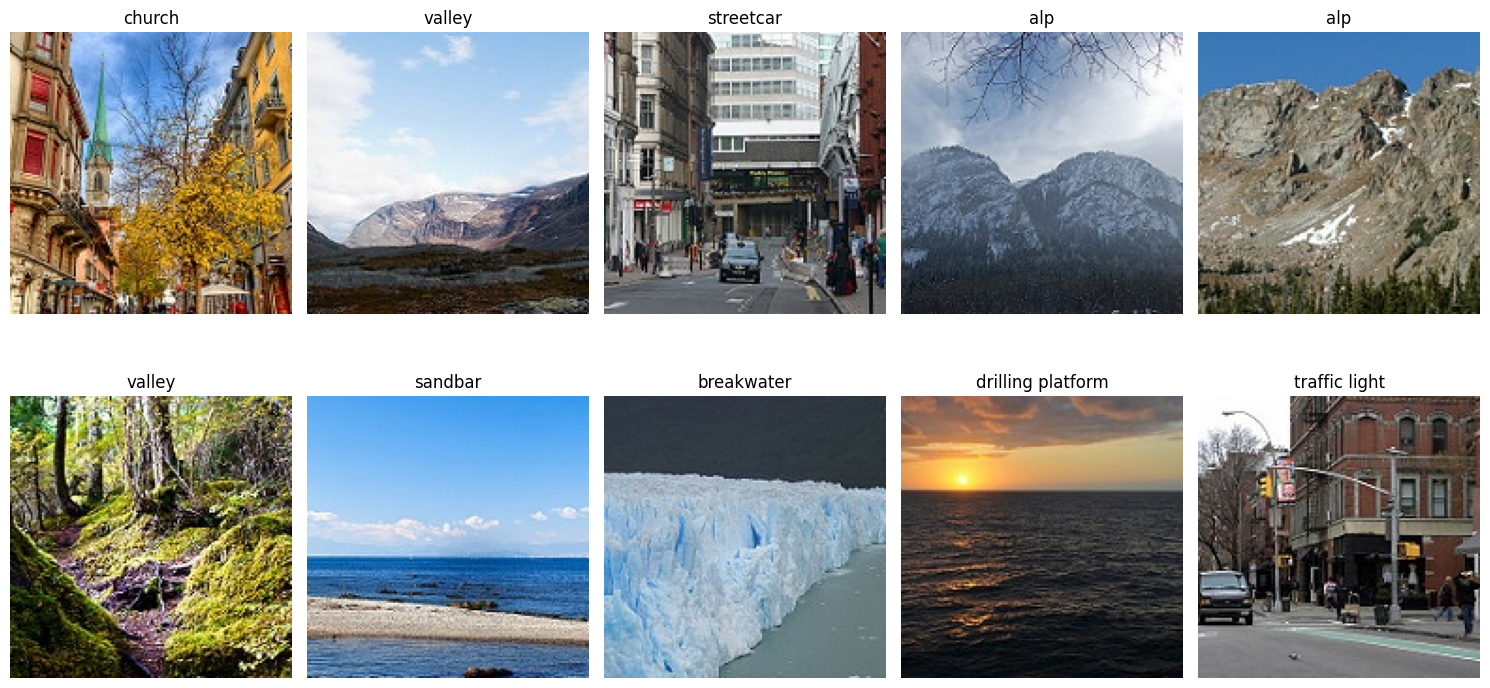

In [57]:
import torch
import torchvision.models as models
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import os
import requests

# Load pretrained ResNet50
model = models.resnet50(pretrained=True)
model.eval()

# Preprocessing (ImageNet normalization)
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406], 
        std=[0.229, 0.224, 0.225]
    )
])

# Load ImageNet class labels
LABELS_URL = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"
imagenet_classes = requests.get(LABELS_URL).text.splitlines()

test_folder = "intel_dataset/seg_pred/seg_pred"
files = os.listdir(test_folder)[:10]

plt.figure(figsize=(15, 8))

for idx, file in enumerate(files):
    img_path = os.path.join(test_folder, file)
    img = Image.open(img_path)

    input_tensor = preprocess(img).unsqueeze(0)

    with torch.no_grad():
        outputs = model(input_tensor)
    pred = outputs.argmax(-1).item()
    label = imagenet_classes[pred]

    plt.subplot(2, 5, idx + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(label)

plt.tight_layout()
plt.show()


In [58]:
model = models.efficientnet_b0(pretrained=True)
model.eval()

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth
100%|███████████████████████████████████████████████████████████████████████████████| 20.5M/20.5M [00:00<00:00, 270MB/s]


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat